In [1]:
!nvidia-smi

Mon Mar  9 09:54:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install vLLM + utilities
!pip install -q vllm lm-format-enforcer pandas datasets scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.9/432.9 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.

In [3]:
# Need to install this version of protobuf after installing vllm
!pip install "protobuf==5.29.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 29.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.5
    Uninstalling protobuf-6.33.5:
      Successfully uninstalled protobuf-6.33.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-reflection 1.78.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 5.29.5 which is incompatible.
vllm 0.17.0 requires protobuf!=6.30.*,!=6.31.*,!=6.32.*,!=6.33.0.*,!=6.33.1.*,!=6.33.2.*,!=6.33.3.*,!=6.33.4.*,>=5.29.6, but you have protobuf 5.29.5 which is incompatible.
google-adk 1.26.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0 which is incompatible.
google-adk 1.26.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 require

In [4]:
# IFBench evaluation dependencies
!pip install -q langdetect nltk immutabledict spacy emoji syllapy unicodedata2 absl-py
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 53.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 48.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 156.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [6]:
import os
import json
import time
import numpy as np
from datasets import load_dataset
from collections import Counter, defaultdict

print("Imports OK")

Imports OK


# IFBench — 0-shot Evaluation with LLama3-8B + vLLM

**Benchmark:** [IFBench](https://github.com/allenai/IFBench) (AllenAI, NeurIPS 2025)  
**Dataset:** [`allenai/IFBench_test`](https://huggingface.co/datasets/allenai/IFBench_test) — 300 examples with 58 diverse verifiable constraints  
**Model:** meta-llama/Meta-Llama-3-8B-Instruct (non-thinking mode)  
**Method:** 0-shot instruction following; temperature=0  
**Evaluation:** Official IFBench constraint verification (cloned from allenai/IFBench repo)

In [7]:
# --- Config ---
MODEL_NAME       = "meta-llama/Meta-Llama-3-8B-Instruct"
MAX_NEW_TOKENS   = 2048
ENABLE_THINKING  = False # not used for llama

print({
    "model": MODEL_NAME,
    "max_new_tokens": MAX_NEW_TOKENS,
    "enable_thinking": ENABLE_THINKING,
})

{'model': 'meta-llama/Meta-Llama-3-8B-Instruct', 'max_new_tokens': 2048, 'enable_thinking': False}


In [8]:
# --- Load dataset ---
print("Loading IFBench test set...")
ds = load_dataset("allenai/IFBench_test", split="train")

print(f"Dataset size: {len(ds)} examples")
print(f"Columns: {ds.column_names}")

# Constraint type distribution
constraint_counts = Counter()
for example in ds:
    for iid in example["instruction_id_list"]:
        constraint_counts[iid] += 1

total_constraints = sum(constraint_counts.values())
print(f"\nUnique constraint types: {len(constraint_counts)}")
print(f"Total constraints across all examples: {total_constraints}")
print(f"Mean constraints per example: {total_constraints / len(ds):.1f}")

Loading IFBench test set...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/94.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/300 [00:00<?, ? examples/s]

Dataset size: 300 examples
Columns: ['key', 'prompt', 'instruction_id_list', 'kwargs']

Unique constraint types: 58
Total constraints across all examples: 344
Mean constraints per example: 1.1


In [9]:
from huggingface_hub import login
login()

In [10]:
# --- Load model ---
if __name__ == '__main__':
  from transformers import AutoTokenizer
  from vllm import LLM, SamplingParams

  print("Loading tokenizer...")
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

  print("Loading Llama-3-8B-Instruct with vLLM...")
  print("  PagedAttention: enabled (automatic)")
  print("  Cont. batching: enabled (automatic)")

  llm = LLM(
      model=MODEL_NAME,
      dtype="float16",
      gpu_memory_utilization=0.95,
      max_model_len=4096,
      enforce_eager=False,
  )

  sampling_params = SamplingParams(
      temperature=0,
      top_k=20,
      max_tokens=MAX_NEW_TOKENS,
  )

  print("Model loaded successfully!")

Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loading Llama-3-8B-Instruct with vLLM...
  PagedAttention: enabled (automatic)
  Cont. batching: enabled (automatic)
INFO 03-09 09:57:41 [utils.py:238] non-default args: {'dtype': 'float16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.95, 'disable_log_stats': True, 'model': 'meta-llama/Meta-Llama-3-8B-Instruct'}


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

INFO 03-09 09:58:03 [model.py:531] Resolved architecture: LlamaForCausalLM
WARNING 03-09 09:58:03 [model.py:1892] Casting torch.bfloat16 to torch.float16.
INFO 03-09 09:58:03 [model.py:1554] Using max model len 4096
INFO 03-09 09:58:03 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 03-09 09:58:03 [vllm.py:747] Asynchronous scheduling is enabled.


generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

WARNING 03-09 09:58:05 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 03-09 10:00:09 [llm.py:388] Supported tasks: ['generate']
Model loaded successfully!


In [11]:
# --- Output directory (Colab Drive if available) ---
IN_COLAB = True
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_SAVE_DIR = "/content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM"
else:
    DRIVE_SAVE_DIR = os.path.abspath("./llama3_8b_ifbench_eval_vllm_outputs")

os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"Saving results to: {DRIVE_SAVE_DIR}")

Mounted at /content/drive
Saving results to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM


In [12]:
def build_prompt(user_prompt: str) -> str:
    """Wrap the IFBench prompt in the Llama 3 chat template."""
    messages = [
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

all_prompts = [build_prompt(example["prompt"]) for example in ds]

print(f"Built {len(all_prompts)} prompts.")
if all_prompts:
    print("\nExample prompt (first 500 chars):")
    print(all_prompts[0][:500])

Built 300 prompts.

Example prompt (first 500 chars):
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

What should the world's smartest man, surrounded by corruption, greed, inequity, madness, inequality, an establishment who preached conspiracy theories and wild speculations over truth and an equally evil resistance funded by the mega rich, along with a worldwide mafia and the sellout who support it, do with his life? Should be burn it all down and let flames consume the corruption? Hypothetical question, no judgement or bad here. Includ


In [13]:
print(f"Generating responses for {len(all_prompts)} prompts...")
print(f"  max_new_tokens = {MAX_NEW_TOKENS}")
print(f"  temperature    = 0")

gen_start = time.time()
outputs = llm.generate(all_prompts, sampling_params)
gen_time = time.time() - gen_start

total_new_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
throughput = total_new_tokens / gen_time if gen_time > 0 else None

print("\nGeneration complete.")
print(f"  Time:       {gen_time/60:.2f} min")
print(f"  Tokens:     {total_new_tokens:,}")
print(f"  Throughput: {throughput:.1f} tokens/sec" if throughput else "  Throughput: N/A")

Generating responses for 300 prompts...
  max_new_tokens = 2048
  temperature    = 0


Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/300 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Generation complete.
  Time:       4.03 min
  Tokens:     126,624
  Throughput: 523.7 tokens/sec


In [14]:
def strip_thinking(text: str) -> str:
    """Remove <think>...</think> blocks if thinking mode leaked."""
    if "</think>" in text:
        return text.split("</think>", 1)[-1].strip()
    return text

responses = [strip_thinking(o.outputs[0].text) for o in outputs]

print(f"Extracted {len(responses)} responses")

# Response length stats
lengths = [len(r.split()) for r in responses]
print(f"\nResponse length stats (words):")
print(f"  Mean:   {np.mean(lengths):.0f}")
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Median: {int(np.median(lengths))}")

print(f"\n== Example response (first 300 chars) ==")
print(responses[0][:300])
print("...")

Extracted 300 responses

Response length stats (words):
  Mean:   298
  Min:    1
  Max:    1823
  Median: 269

== Example response (first 300 chars) ==
What a thought-provoking and complex question! As the world's smartest man, surrounded by the chaos you've described, I would propose a multifaceted approach to address the issues at hand. Here's a possible path:

Firstly, I would acknowledge that the situation is a labyrinth of complexities, with m
...


In [15]:
# Save raw outputs cache (for debugging / re-evaluation)
raw_cache = [
    {
        "idx": i,
        "prompt": ds[i]["prompt"],
        "instruction_id_list": ds[i]["instruction_id_list"],
        "response": responses[i],
        "n_tokens": len(outputs[i].outputs[0].token_ids),
    }
    for i in range(len(ds))
]

OUTPUTS_CACHE = os.path.join(DRIVE_SAVE_DIR, "llama3_8b_ifbench_raw_outputs.json")
with open(OUTPUTS_CACHE, "w") as f:
    json.dump(raw_cache, f)
print(f"Raw outputs saved to: {OUTPUTS_CACHE}")

# Save in the JSONL format that IFBench evaluation expects: {"prompt": ..., "response": ...}
RESPONSE_FILE = os.path.join(DRIVE_SAVE_DIR, "llama3_8b_responses.jsonl")
with open(RESPONSE_FILE, "w") as f:
    for example, response in zip(ds, responses):
        f.write(json.dumps({"prompt": example["prompt"], "response": response}) + "\n")
print(f"Response JSONL saved to: {RESPONSE_FILE}")

# Save the test data as JSONL so the eval functions can read it
TEST_DATA_FILE = os.path.join(DRIVE_SAVE_DIR, "IFBench_test.jsonl")
with open(TEST_DATA_FILE, "w") as f:
    for example in ds:
        record = {
            "key": example["key"],
            "prompt": example["prompt"],
            "instruction_id_list": example["instruction_id_list"],
            "kwargs": example["kwargs"],
        }
        f.write(json.dumps(record) + "\n")
print(f"Test data saved to: {TEST_DATA_FILE}")

Raw outputs saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/llama3_8b_ifbench_raw_outputs.json
Response JSONL saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/llama3_8b_responses.jsonl
Test data saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/IFBench_test.jsonl


## Run Official IFBench Evaluation

Uses the cloned `evaluation_lib.py` and `instructions_registry.py` from  
[allenai/IFBench](https://github.com/allenai/IFBench).  

Reports:
- **Prompt-level accuracy** (strict & loose): fraction of prompts where *all* constraints pass  
- **Instruction-level accuracy**: fraction of individual constraints satisfied across all prompts

In [16]:
# --- Clone IFBench evaluation code ---
!rm -rf /content/IFBench
!git clone https://github.com/allenai/IFBench.git /content/IFBench

import sys
sys.path.insert(0, "/content/IFBench")

import instructions_registry
import evaluation_lib
print(f"IFBench loaded — {len(instructions_registry.INSTRUCTION_DICT)} constraint types registered")

Cloning into '/content/IFBench'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 173 (delta 69), reused 66 (delta 47), pack-reused 76 (from 1)
Receiving objects: 100% (173/173), 2.89 MiB | 3.46 MiB/s, done.
Resolving deltas: 100% (87/87), done.
IFBench loaded — 58 constraint types registered


/usr/local/lib/python3.12/dist-packages/syllapy/data_loader.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [17]:
# Load inputs & responses using official IFBench functions
inputs = evaluation_lib.read_prompt_list(TEST_DATA_FILE)
prompt_to_response = evaluation_lib.read_prompt_to_response_dict(RESPONSE_FILE)

print(f"Loaded {len(inputs)} test inputs")
print(f"Loaded {len(prompt_to_response)} prompt-response pairs")

# Verify all prompts have responses
missing = [inp.prompt[:80] for inp in inputs if inp.prompt not in prompt_to_response]
if missing:
    print(f"WARNING: {len(missing)} prompts have no response!")
    for m in missing[:5]:
        print(f"  {m}...")
else:
    print("All prompts matched to responses.")

Loaded 300 test inputs
Loaded 300 prompt-response pairs
All prompts matched to responses.


In [18]:
# --- Strict evaluation ---
print("Running STRICT evaluation...")
strict_outputs = []
for inp in inputs:
    strict_outputs.append(
        evaluation_lib.test_instruction_following_strict(inp, prompt_to_response)
    )

strict_follow_all = [o.follow_all_instructions for o in strict_outputs]
strict_prompt_acc = sum(strict_follow_all) / len(strict_outputs)

strict_instr_total = 0
strict_instr_correct = 0
for o in strict_outputs:
    strict_instr_total += len(o.follow_instruction_list)
    strict_instr_correct += sum(o.follow_instruction_list)
strict_instr_acc = strict_instr_correct / strict_instr_total

print(f"  Strict prompt-level accuracy:      {strict_prompt_acc:.4f} ({sum(strict_follow_all)}/{len(strict_outputs)})")
print(f"  Strict instruction-level accuracy:  {strict_instr_acc:.4f} ({strict_instr_correct}/{strict_instr_total})")

strict_file = os.path.join(DRIVE_SAVE_DIR, "eval_results_strict.jsonl")
evaluation_lib.write_outputs(strict_file, strict_outputs)
print(f"  Saved to: {strict_file}")

Running STRICT evaluation...
  Strict prompt-level accuracy:      0.2133 (64/300)
  Strict instruction-level accuracy:  0.2326 (80/344)
  Saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/eval_results_strict.jsonl


In [19]:
# --- Loose evaluation (this is what the paper primarily reports) ---
print("Running LOOSE evaluation...")
loose_outputs = []
for inp in inputs:
    loose_outputs.append(
        evaluation_lib.test_instruction_following_loose(inp, prompt_to_response)
    )

loose_follow_all = [o.follow_all_instructions for o in loose_outputs]
loose_prompt_acc = sum(loose_follow_all) / len(loose_outputs)

loose_instr_total = 0
loose_instr_correct = 0
for o in loose_outputs:
    loose_instr_total += len(o.follow_instruction_list)
    loose_instr_correct += sum(o.follow_instruction_list)
loose_instr_acc = loose_instr_correct / loose_instr_total

print(f"  Loose prompt-level accuracy:      {loose_prompt_acc:.4f} ({sum(loose_follow_all)}/{len(loose_outputs)})")
print(f"  Loose instruction-level accuracy:  {loose_instr_acc:.4f} ({loose_instr_correct}/{loose_instr_total})")

loose_file = os.path.join(DRIVE_SAVE_DIR, "eval_results_loose.jsonl")
evaluation_lib.write_outputs(loose_file, loose_outputs)
print(f"  Saved to: {loose_file}")

Running LOOSE evaluation...
  Loose prompt-level accuracy:      0.2867 (86/300)
  Loose instruction-level accuracy:  0.3198 (110/344)
  Saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/eval_results_loose.jsonl


## Per-Constraint Breakdown

In [20]:
import pandas as pd

# Per-constraint accuracy (using loose eval — the paper's primary metric)
constraint_total = defaultdict(int)
constraint_correct = defaultdict(int)

for o in loose_outputs:
    for iid, followed in zip(o.instruction_id_list, o.follow_instruction_list):
        constraint_total[iid] += 1
        if followed:
            constraint_correct[iid] += 1

constraint_rows = []
for cid in sorted(constraint_total.keys()):
    total = constraint_total[cid]
    correct = constraint_correct[cid]
    constraint_rows.append({
        "constraint": cid,
        "correct": correct,
        "total": total,
        "accuracy": correct / total,
    })

constraint_df = pd.DataFrame(constraint_rows).sort_values("accuracy", ascending=False)

print("PER-CONSTRAINT ACCURACY (Loose)")
print("=" * 60)
print(constraint_df.to_string(index=False))

print(f"\nConstraints with 100% accuracy: {len(constraint_df[constraint_df['accuracy'] == 1.0])}")
print(f"Constraints with   0% accuracy: {len(constraint_df[constraint_df['accuracy'] == 0.0])}")

PER-CONSTRAINT ACCURACY (Loose)
                      constraint  correct  total  accuracy
               custom:csv_quotes        1      1  1.000000
                 custom:csv_city        1      1  1.000000
         custom:mcq_count_length        1      1  1.000000
             custom:word_reverse        1      1  1.000000
        custom:sentence_alphabet        1      1  1.000000
                custom:multiples        1      1  1.000000
    custom:csv_special_character        1      1  1.000000
              format:sub-bullets       12     12  1.000000
          format:output_template        4      4  1.000000
                  format:options        6      6  1.000000
         count:unique_word_count        8      9  0.888889
                words:palindrome        6      7  0.857143
                words:start_verb        5      6  0.833333
            format:quote_unquote        4      5  0.800000
                  count:pronouns        6      8  0.750000
                    form

## Final Summary & Save Metrics


In [21]:
print("\n" + "=" * 60)
print("IFBENCH 0-SHOT EVALUATION SUMMARY")
print(f"Model: {MODEL_NAME}")
print("=" * 60)
print(f"  Dataset:                       allenai/IFBench_test")
print(f"  Number of prompts:             {len(ds)}")
print(f"  Total constraints evaluated:   {strict_instr_total}")
print(f"  Unique constraint types:       {len(constraint_total)}")
print(f"")
print(f"  Strict prompt-level accuracy:  {strict_prompt_acc:.4f}")
print(f"  Strict instr-level accuracy:   {strict_instr_acc:.4f}")
print(f"  Loose prompt-level accuracy:   {loose_prompt_acc:.4f}  <-- paper's primary metric")
print(f"  Loose instr-level accuracy:    {loose_instr_acc:.4f}")
print(f"")
print(f"  Total new tokens generated:    {total_new_tokens:,}")
print(f"  Throughput:                    {throughput:.1f} tokens/sec" if throughput else "  Throughput: N/A")
print(f"  Total generation time:         {gen_time/60:.2f} min")
print("=" * 60)

# Reference: IFBench leaderboard (from allenai/IFBench README)
print("\nReference (IFBench leaderboard, loose prompt-level):")
print(f"  OpenAI o3:       69.3%")
print(f"  Qwen 3 32B:      37.3%")
print(f"  Qwen 3 8B:       35.0%  <-- official baseline")
print(f"  DeepSeek R1:     38.0%")


IFBENCH 0-SHOT EVALUATION SUMMARY
Model: meta-llama/Meta-Llama-3-8B-Instruct
  Dataset:                       allenai/IFBench_test
  Number of prompts:             300
  Total constraints evaluated:   344
  Unique constraint types:       58

  Strict prompt-level accuracy:  0.2133
  Strict instr-level accuracy:   0.2326
  Loose prompt-level accuracy:   0.2867  <-- paper's primary metric
  Loose instr-level accuracy:    0.3198

  Total new tokens generated:    126,624
  Throughput:                    523.7 tokens/sec
  Total generation time:         4.03 min

Reference (IFBench leaderboard, loose prompt-level):
  OpenAI o3:       69.3%
  Qwen 3 32B:      37.3%
  Qwen 3 8B:       35.0%  <-- official baseline
  DeepSeek R1:     38.0%


In [22]:
final_metrics = {
    "method":                        f"0_shot_vllm_thinking={ENABLE_THINKING}",
    "model":                         MODEL_NAME,
    "dataset":                       "allenai/IFBench_test",
    "eval_size":                     len(ds),
    "total_constraints":             strict_instr_total,
    "unique_constraint_types":       len(constraint_total),
    "strict_prompt_accuracy":        round(strict_prompt_acc, 4),
    "strict_instruction_accuracy":   round(strict_instr_acc, 4),
    "loose_prompt_accuracy":         round(loose_prompt_acc, 4),
    "loose_instruction_accuracy":    round(loose_instr_acc, 4),
    "total_new_tokens":              total_new_tokens,
    "gen_tokens_per_sec":            round(throughput, 2) if throughput else "N/A",
    "total_gen_time_min":            round(gen_time / 60, 3),
}

print("\n=== Final Metrics ===")
for k, v in final_metrics.items():
    print(f"  {k}: {v}")

METRICS_FILE = os.path.join(DRIVE_SAVE_DIR, "qwen_3_8b_ifbench_0shot_final_metrics.json")
with open(METRICS_FILE, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"\nMetrics saved to: {METRICS_FILE}")

# Save per-constraint breakdown
CONSTRAINT_FILE = os.path.join(DRIVE_SAVE_DIR, "per_constraint_accuracy.json")
with open(CONSTRAINT_FILE, "w") as f:
    json.dump(constraint_rows, f, indent=2)
print(f"Per-constraint breakdown saved to: {CONSTRAINT_FILE}")


=== Final Metrics ===
  method: 0_shot_vllm_thinking=False
  model: meta-llama/Meta-Llama-3-8B-Instruct
  dataset: allenai/IFBench_test
  eval_size: 300
  total_constraints: 344
  unique_constraint_types: 58
  strict_prompt_accuracy: 0.2133
  strict_instruction_accuracy: 0.2326
  loose_prompt_accuracy: 0.2867
  loose_instruction_accuracy: 0.3198
  total_new_tokens: 126624
  gen_tokens_per_sec: 523.74
  total_gen_time_min: 4.029

Metrics saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/qwen_3_8b_ifbench_0shot_final_metrics.json
Per-constraint breakdown saved to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/per_constraint_accuracy.json


/tmp/ipykernel_3724/754544412.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [cm.get_cmap("RdYlGn")(v) for v in sorted_df["accuracy"]]


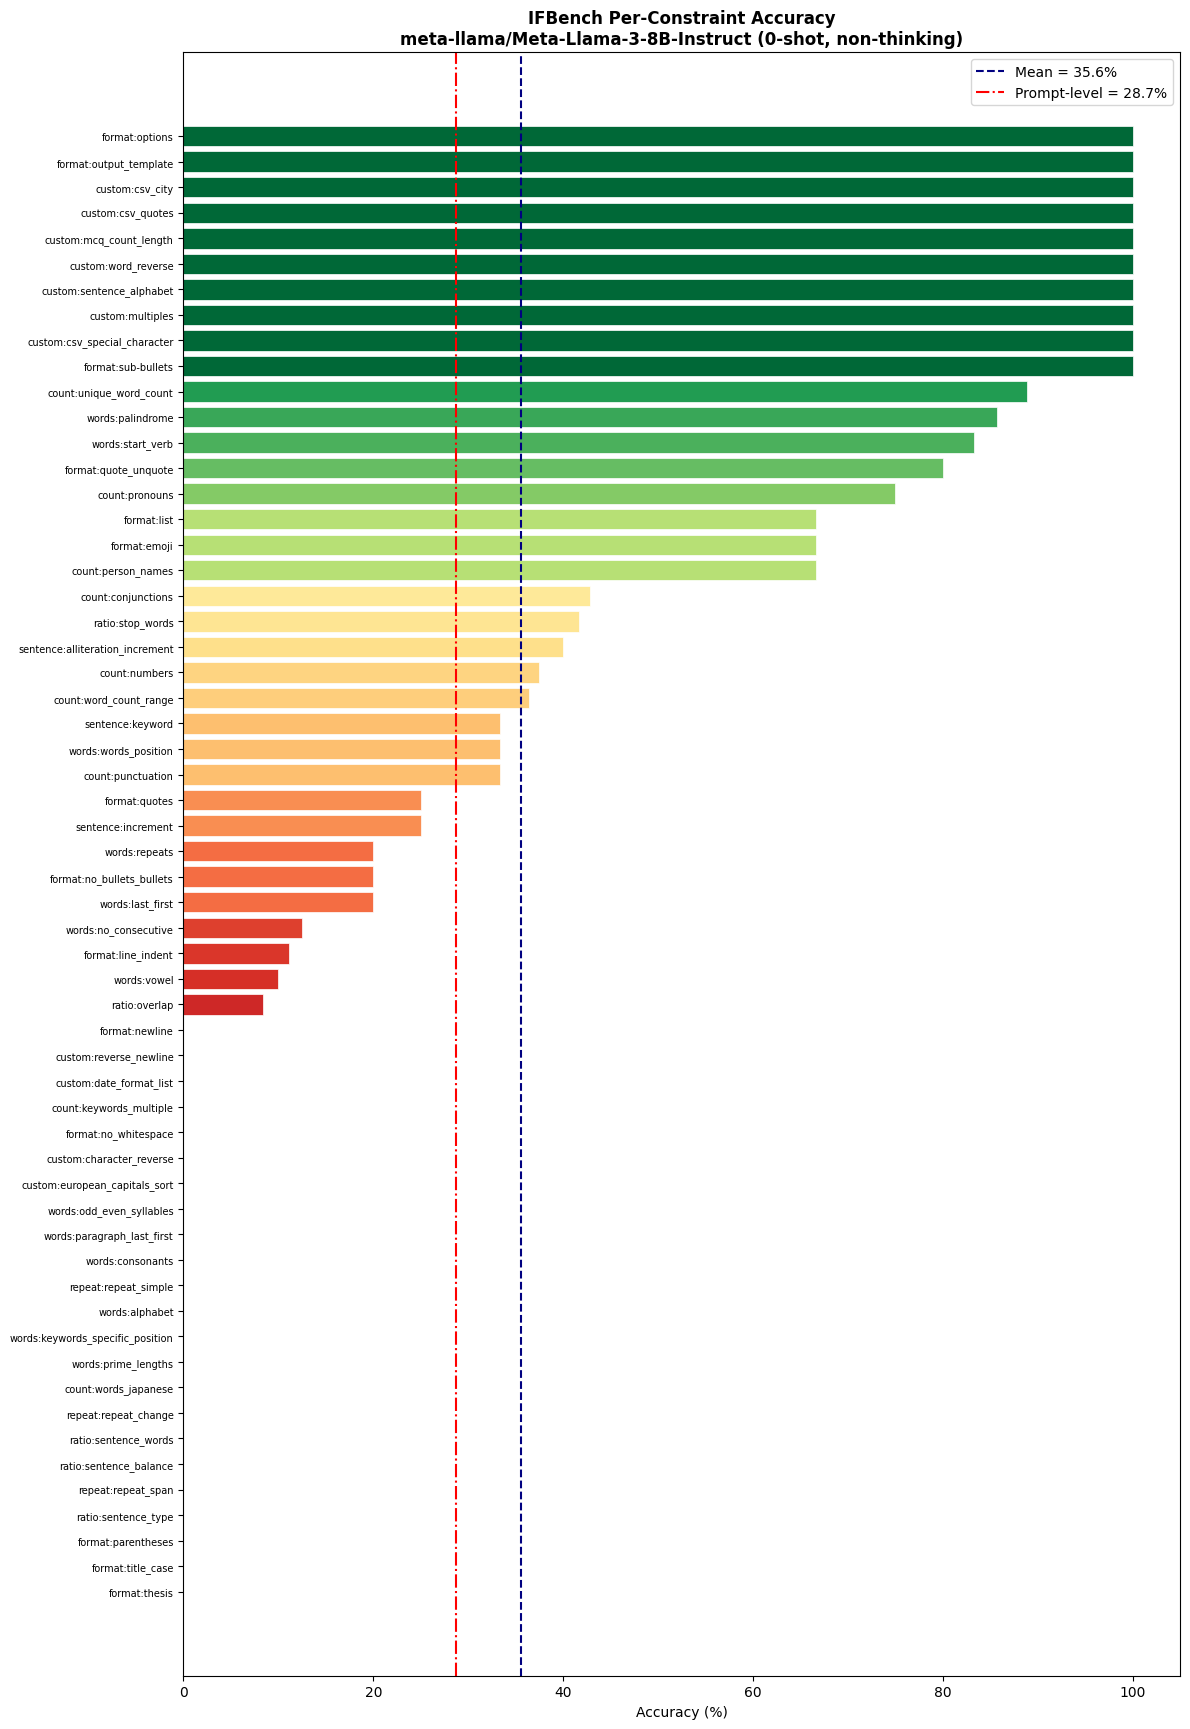

Saved figure to: /content/drive/MyDrive/Colab_Data/IFBench/llama3_8B_IFBench_Eval_vLLM/per_constraint_accuracy.png


In [23]:
# --- Visualize per-constraint accuracy ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, max(8, len(constraint_df) * 0.3)))

sorted_df = constraint_df.sort_values("accuracy", ascending=True)
colors = [cm.get_cmap("RdYlGn")(v) for v in sorted_df["accuracy"]]

bars = ax.barh(sorted_df["constraint"], sorted_df["accuracy"] * 100,
               color=colors, edgecolor="white", linewidth=0.5)

mean_acc = constraint_df["accuracy"].mean() * 100
ax.axvline(mean_acc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_acc:.1f}%")
ax.axvline(loose_prompt_acc * 100, color="red", linestyle="-.", linewidth=1.5,
           label=f"Prompt-level = {loose_prompt_acc*100:.1f}%")

ax.set_xlabel("Accuracy (%)")
ax.set_title(f"IFBench Per-Constraint Accuracy\n{MODEL_NAME} (0-shot, non-thinking)",
             fontweight="bold")
ax.set_xlim(0, 105)
ax.legend(fontsize=10)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
fig_file = os.path.join(DRIVE_SAVE_DIR, "per_constraint_accuracy.png")
plt.savefig(fig_file, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {fig_file}")

In [24]:
# --- Show a few example outputs ---
print("SAMPLE RESULTS (first 5 examples)")
print("=" * 60)

for i in range(min(5, len(loose_outputs))):
    o = loose_outputs[i]
    print(f"\n--- Example {i} ---")
    print(f"  Prompt (first 100):  {o.prompt[:100]}...")
    print(f"  Constraints:         {o.instruction_id_list}")
    print(f"  All satisfied:       {o.follow_all_instructions}")
    print(f"  Per-constraint:      {o.follow_instruction_list}")
    print(f"  Response (first 200): {o.response[:200]}...")

SAMPLE RESULTS (first 5 examples)

--- Example 0 ---
  Prompt (first 100):  What should the world's smartest man, surrounded by corruption, greed, inequity, madness, inequality...
  Constraints:         ['count:keywords_multiple']
  All satisfied:       False
  Per-constraint:      [False]
  Response (first 200): What a thought-provoking and complex question! As the world's smartest man, surrounded by the chaos you've described, I would propose a multifaceted approach to address the issues at hand. Here's a po...

--- Example 1 ---
  Prompt (first 100):  What is the female equivalent to chivalry? Include keyword meridian once in your response, keyword g...
  Constraints:         ['count:keywords_multiple']
  All satisfied:       False
  Per-constraint:      [False]
  Response (first 200): What a delightful challenge!

The female equivalent to chivalry is often referred to as "feminine courtesy" or "ladylike behavior." However, I'd like to propose a more poetic and evocative term: "Ecli